In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("../data/customers_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
loan_defaults = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)

loan_defaults['Default_Flag'] = loan_defaults['Default_Amount'].notnull().astype(int)

In [4]:
loan_defaults = loan_defaults.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)

In [5]:
corr_data = loan_defaults[
    ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
].corr()

corr_data

,Loan_Amount,Interest_Rate,Credit_Score,Default_Flag
Loan_Amount,1.000000,-0.003451,0.000262,-0.002401
Interest_Rate,-0.003451,1.000000,0.002498,-0.004763
Credit_Score,0.000262,0.002498,1.000000,-0.001724
Default_Flag,-0.002401,-0.004763,-0.001724,1.000000


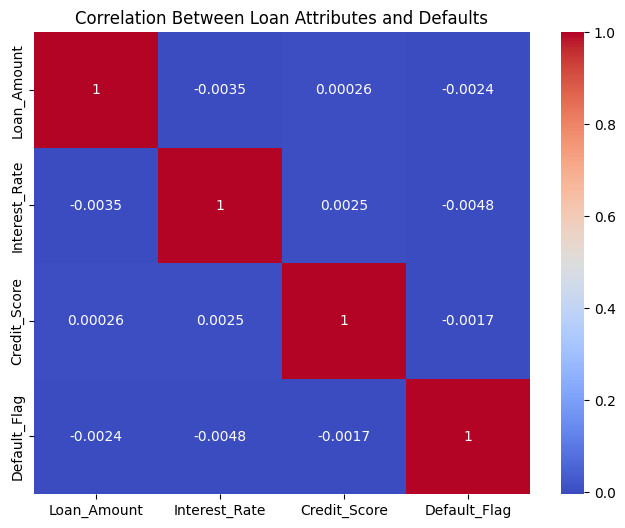

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Correlation Between Loan Attributes and Defaults")
plt.show()

In [7]:
loan_defaults['Credit_Score_Band'] = pd.cut(
    loan_defaults['Credit_Score'],
    bins=[300, 600, 700, 850],
    labels=['Low', 'Medium', 'High']
)

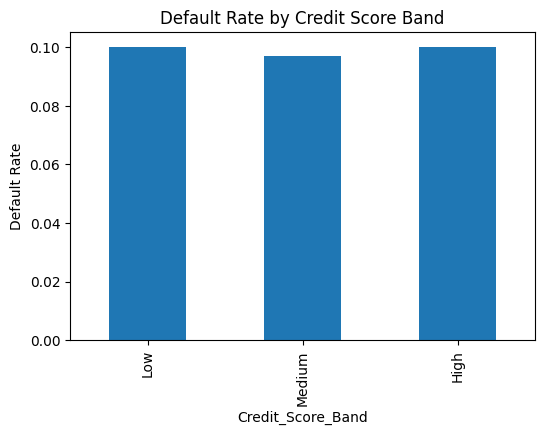

In [8]:
default_rate = loan_defaults.groupby('Credit_Score_Band')['Default_Flag'].mean()

default_rate.plot(kind='bar', figsize=(6,4))
plt.title("Default Rate by Credit Score Band")
plt.ylabel("Default Rate")
plt.show()

In [19]:
print("Branches columns:", branches.columns.tolist())
print("Loans columns:", loans.columns.tolist())
print("Defaults columns:", defaults.columns.tolist())

Branches columns: ['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count']
Loans columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']
Defaults columns: ['Default_ID', 'Loan_ID', 'Customer_ID', 'Default_Date', 'Default_Amount', 'Default_Reason', 'Recovery_Status', 'Recovery_Amount', 'Legal_Action']


In [22]:
print("Branches columns:", branches.columns.tolist())
print("Loans columns:", loans.columns.tolist())

Branches columns: ['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count']
Loans columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']


In [24]:
print("Available columns in Loans:", loans.columns.tolist())

Available columns in Loans: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']


In [31]:
branches['Branch_Default_Rate'] = (
    branches['Delinquent_Loans'] / branches['Total_Active_Loans']
)

branches[['Branch_ID', 'Region', 'Branch_Default_Rate']].sort_values(
    by='Branch_Default_Rate',
    ascending=False
).head()

,Branch_ID,Region,Branch_Default_Rate
2,B003,Central,1.377049
31,B032,Northeast,0.681275
7,B008,Central,0.513158
8,B009,North,0.449153
6,B007,North,0.427350


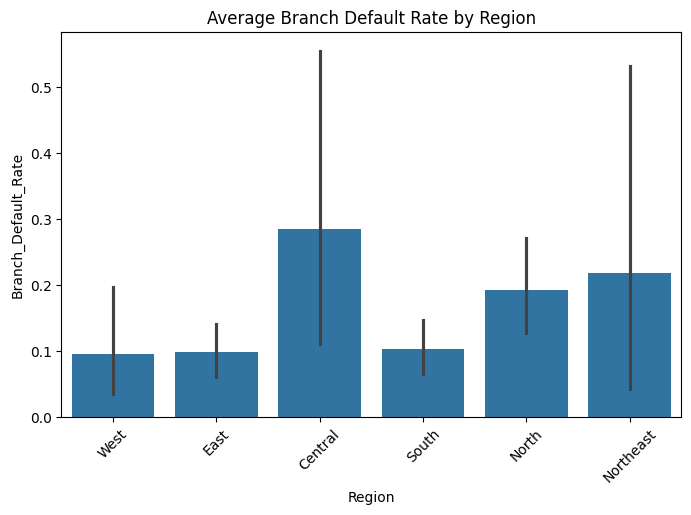

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Region',
    y='Branch_Default_Rate',
    data=branches
)
plt.title("Average Branch Default Rate by Region")
plt.xticks(rotation=45)
plt.show()

### Branch-Level Default Insights
- Branch default rates were derived using delinquent loan ratios
- Certain regions show consistently higher default exposure
- Branch operational efficiency directly impacts default outcomes